In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import MarkerCluster

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from lightgbm import LGBMClassifier
from sklearn.cluster import KMeans
sns.set_theme()

In [18]:
df_map = pd.read_csv(
    r'C:\Fause\Programas\EngSoft\repos\ML-Transportes\PBIC\Etapa3\acidentes_pbic_2020_2025_Final.csv',
    encoding='utf-8',
    parse_dates=['data_inversa'],
    dayfirst=True,
    low_memory=False
)

print("Shape inicial:", df_map.shape)


Shape inicial: (1678326, 48)


In [19]:
df_map = df_map.copy()

In [20]:
import pandas as pd
import numpy as np
import folium
from folium.plugins import MarkerCluster
from datetime import datetime

# =============================
# 1️⃣ Limpeza e Padronização (O Pulo do Gato)
# =============================


# Função para garantir que a BR seja uma string limpa (ex: "116")
def limpar_br(df):
    return df["br"].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_map["br"] = limpar_br(df_map)

# =============================
# FILTRO DE RODOVIA (BR)
# =============================

br_escolhida = input("Digite a BR que deseja visualizar (ex: 116) ou pressione ENTER para todas: ")

if br_escolhida.strip() != "":
    df_map = df_map[df_map["br"] == br_escolhida.strip()]
    print(f"Filtrando apenas BR {br_escolhida}")
else:
    print("Mostrando todas as rodovias")

if df_map.empty:
    print("Nenhum dado encontrado para essa BR.")
    exit()
# Limpeza de coordenadas e KM
cols = ["latitude", "longitude", "km"]
for col in cols:
    df_map[col] = pd.to_numeric(df_map[col].astype(str).str.replace(",", "."), errors="coerce")

df_map = df_map.dropna(subset=["latitude", "longitude", "km"])
df_map["km_bin"] = (df_map["km"] // 5) * 5

# =============================
# 2️⃣ Agregação
# =============================

# Cálculo de severidade no DF original
df_map["severity_index"] = (4 * df_map["mortos"] + 2 * df_map["feridos_graves"] + 1 * df_map["feridos_leves"])

df_segmento = df_map.groupby(["br", "uf", "km_bin"]).agg(
    severity_index=("severity_index", "mean"),
    n_acidentes=("severity_index", "count"),
    total_mortos=("mortos", "sum"),
    total_feridos_graves=("feridos_graves", "sum"),
    total_feridos_leves=("feridos_leves", "sum")
).reset_index()

df_segmento["risk_score"] = df_segmento["severity_index"] * np.log1p(df_segmento["n_acidentes"])
df_segmento["taxa_mortalidade"] = df_segmento["total_mortos"] / df_segmento["n_acidentes"]

def classificar_gravidade(row):
    if row["total_mortos"] > 0: return "Acidente com mortos"
    if (row["total_feridos_graves"] > 0) or (row["total_feridos_leves"] > 0): return "Sinistro de média gravidade"
    return "Sinistro sem gravidade"

df_segmento["gravidade"] = df_segmento.apply(classificar_gravidade, axis=1)

# =============================
# 3️⃣ Mapa e Plotagem
# =============================

m = folium.Map(
    location=[df_map["latitude"].median(), df_map["longitude"].median()],
    zoom_start=6,
    #tiles="CartoDB positron" # Evita o erro 403 Access Blocked
)

# Camadas
layers = {
    "Acidente com mortos": MarkerCluster(name="🔴 Acidente com mortos").add_to(m),
    "Sinistro de média gravidade": MarkerCluster(name="🟠 Média gravidade").add_to(m),
    "Sinistro sem gravidade": MarkerCluster(name="🟢 Sem gravidade").add_to(m)
}

segmentos_grupo = df_map.groupby(["br", "uf", "km_bin"])

for _, row in df_segmento.iterrows():
    try:
        # Busca o grupo usando as chaves limpas
        grupo = segmentos_grupo.get_group((row["br"], row["uf"], row["km_bin"]))
        # Ordena pelo KM e pega o primeiro ponto (início do trecho)
        ponto_ref = grupo.sort_values("km").iloc[0]

        lat = ponto_ref["latitude"]
        lon = ponto_ref["longitude"]
    except KeyError:
        continue # Se não achar, pula

    # Define cor
    cor = "red" if row["gravidade"] == "Acidente com mortos" else "orange" if row["gravidade"] == "Sinistro de média gravidade" else "green"

    # Popup
    veiculos = grupo["tipo_veiculo"].value_counts().head(3)
    veiculo_txt = "<br>".join([f"{v}: {c}" for v, c in veiculos.items()])

    popup_html = f"""
<b>BR:</b> {row['br']} - {row['uf']} | <b>KM:</b> {row['km_bin']}<br>
<b>Gravidade:</b> {row['gravidade']}<br>

<hr>
<b> Estatísticas do trecho:</b><br>
• Total de acidentes: {row['n_acidentes']}<br>
• Mortos: {row['total_mortos']}<br>
• Feridos graves: {row['total_feridos_graves']}<br>
• Feridos leves: {row['total_feridos_leves']}<br>

<hr>
<b> Top Veículos:</b><br>
{veiculo_txt}
"""

    # CircleMarker é melhor que Circle porque o tamanho é fixo em pixels
    folium.CircleMarker(
        location=[lat, lon],
        radius=7 + (np.log1p(row["total_mortos"]) * 3),
        color=cor,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(layers[row["gravidade"]])

folium.LayerControl().add_to(m)
path = f"C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsGeral/mapa_risco_{datetime.now().strftime('%Y%m%d_%H%M')}.html"
m.save(path)
print(f"Mapa gerado com sucesso em: {path}")

Filtrando apenas BR 101
Mapa gerado com sucesso em: C:/Fause/Programas/EngSoft/repos/ML-Transportes/PBIC/EtapaML/MapsGeral/mapa_risco_20260325_0833.html


In [21]:
print("BRs disponíveis no dataset:")
print(df_map["br"].unique())

BRs disponíveis no dataset:
<StringArray>
['101']
Length: 1, dtype: str


In [22]:
print(df_segmento['total_feridos_graves'].unique())

[  4.   8.   0.  22.   9.   2.  11.  13.   3.  17.  18.   1.  12.  19.
  21.   6.  10.  15.  25.  20.  16.  35.   5.  32.  27.   7.  31. 228.
  30.  14.  28.  49.  24.  50.  54.  44.  26.  63. 100.  40.  61.  41.
  57.  33.  56. 170.  43.  67.  85. 245.  38.  59.  39.  70.  37.  42.
  29. 161. 252. 405. 222. 129.  76. 240. 208. 197.  47.  82.  46.  36.
  48.  23.  68. 224. 404.  83.  60.  45. 166. 213. 233. 124. 127. 372.
 249. 172. 135. 140.  72.  66. 133. 145. 104.  77.  92.  78.  65.  98.
 160. 180.  55.  71.  52.  64.  90. 203. 125. 103.  62.  91. 102. 159.
 149. 226. 263. 147. 256. 311. 112. 130. 121. 231. 450. 701. 714. 391.
  87.  96.  75.  79. 114. 178. 115.  34. 119.  95.  69. 346. 210.]


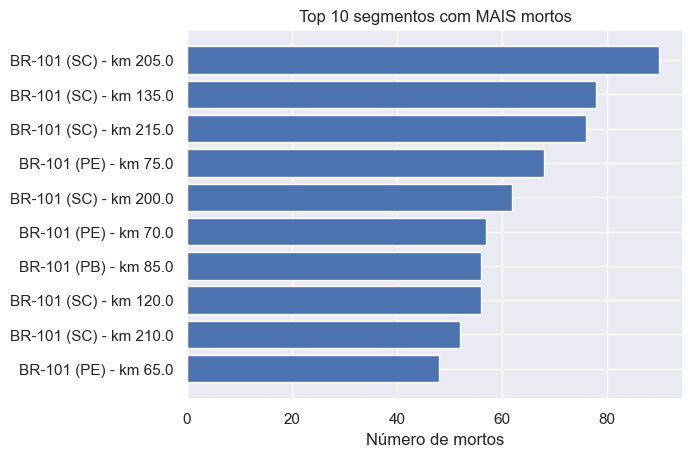

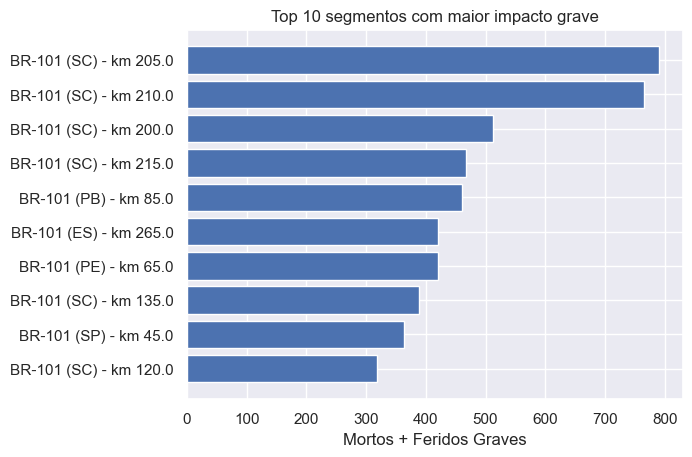

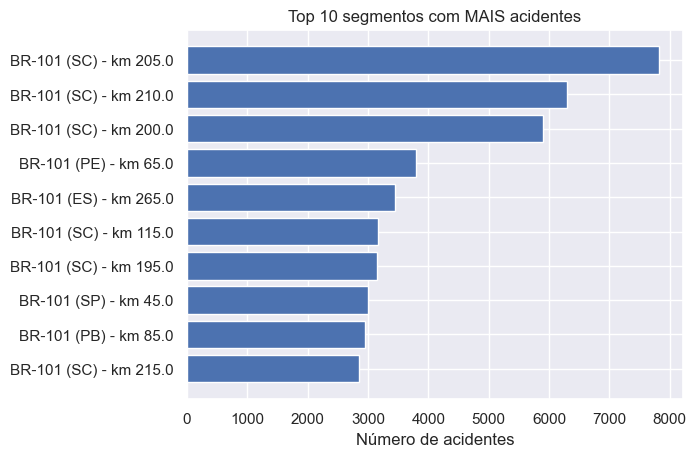

In [28]:
import matplotlib.pyplot as plt

# =============================
# 1️⃣ Filtrar apenas acidentes com mortos
# =============================

df_segmento["br"] = df_segmento["br"].astype(str)

df_mortos = df_segmento[
    df_segmento["gravidade"] == "Acidente com mortos"
].copy()

# =============================
# 2️⃣ TOP 10 - MAIS MORTOS
# =============================

top10_mortos = df_mortos.sort_values(
    "total_mortos", ascending=False
).head(10).copy()

top10_mortos["segmento"] = (
    "BR-" + top10_mortos["br"] + " (" +
    top10_mortos["uf"] + ") - km " +
    top10_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_mortos["segmento"],
    top10_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com MAIS mortos")
plt.gca().invert_yaxis()

plt.show()

# =============================
# 3️⃣ TOP 10 - MAIS IMPACTO GRAVE (Mortos + Feridos Graves)
# =============================

df_segmento["impacto_grave"] = (
    df_segmento["total_mortos"] + df_segmento["total_feridos_graves"]
)

top10_impacto = df_segmento.sort_values(
    "impacto_grave", ascending=False
).head(10).copy()

top10_impacto["segmento"] = (
    "BR-" + top10_impacto["br"] + " (" +
    top10_impacto["uf"] + ") - km " +
    top10_impacto["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_impacto["segmento"],
    top10_impacto["impacto_grave"]
)

plt.xlabel("Mortos + Feridos Graves")
plt.title("Top 10 segmentos com maior impacto grave")
plt.gca().invert_yaxis()

plt.show()
# =============================
# 4️⃣ TOP 10 - MAIS ACIDENTES (Volume)
# =============================

top10_acidentes = df_segmento.sort_values(
    "n_acidentes", ascending=False
).head(10).copy()

top10_acidentes["segmento"] = (
    "BR-" + top10_acidentes["br"] + " (" +
    top10_acidentes["uf"] + ") - km " +
    top10_acidentes["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_acidentes["segmento"],
    top10_acidentes["n_acidentes"]
)

plt.xlabel("Número de acidentes")
plt.title("Top 10 segmentos com MAIS acidentes")
plt.gca().invert_yaxis()

plt.show()

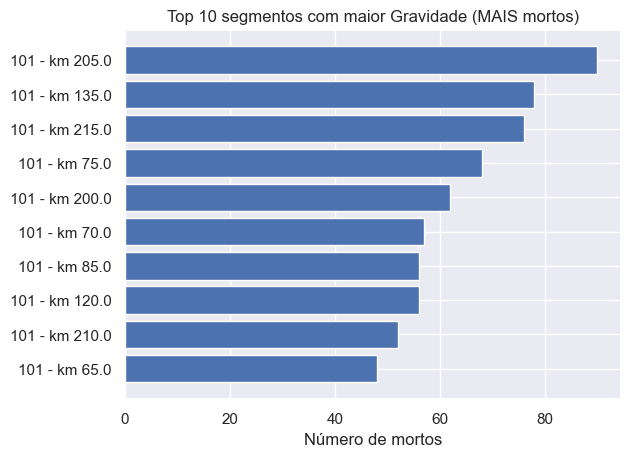

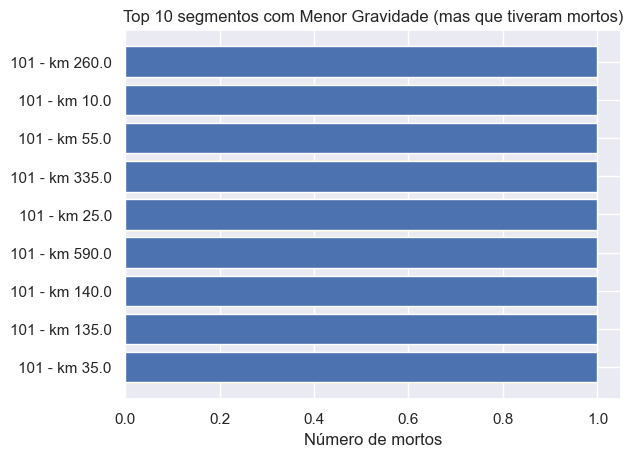

In [24]:
import matplotlib.pyplot as plt

# =============================
# 1️⃣ Filtrar apenas acidentes com mortos
# =============================
df_segmento["br"] = df_segmento["br"].astype(str)
df_mortos = df_segmento[df_segmento["gravidade"] == "Acidente com mortos"].copy()

# Ordenar por número de mortos
df_mortos = df_mortos.sort_values("total_mortos", ascending=False)

# =============================
# 2️⃣ Top 10 com mais mortos
# =============================

top10_mortos = df_mortos.head(10)

top10_mortos["segmento"] = (
    top10_mortos["br"].astype(str) + " - km " +
    top10_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    top10_mortos["segmento"],
    top10_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com maior Gravidade (MAIS mortos)")
plt.gca().invert_yaxis()

plt.show()


# =============================
# 3️⃣ 10 segmentos com menos mortos
# =============================

menos_mortos = df_mortos.tail(10).sort_values("total_mortos")

menos_mortos["segmento"] = (
    menos_mortos["br"].astype(str) + " - km " +
    menos_mortos["km_bin"].astype(str)
)

plt.figure()

plt.barh(
    menos_mortos["segmento"],
    menos_mortos["total_mortos"]
)

plt.xlabel("Número de mortos")
plt.title("Top 10 segmentos com Menor Gravidade (mas que tiveram mortos)")
plt.gca().invert_yaxis()

plt.show()

In [25]:
grupo = df_map[(df_map["br"] == "116") & (df_map["km_bin"] == 10)]

print(grupo[["latitude","longitude"]].head())

Empty DataFrame
Columns: [latitude, longitude]
Index: []


In [26]:
print(grupo[["latitude","longitude"]].mean())

latitude    NaN
longitude   NaN
dtype: float64


In [27]:
for _, row in top10_mortos.iterrows():
    chave = (row["br"], row["km_bin"])
    print(chave in segmentos_grupo.groups)

False
False
False
False
False
False
False
False
False
False
